In [10]:
from sklearn.datasets import make_moons
import pandas as pd
X, y = make_moons(n_samples=2000, noise=0.2, random_state=42)

In [11]:
df = pd.DataFrame(X, columns=['x1','x2'])
df['target'] = y.astype('str')

In [12]:
from sbtab.data.datamodule import TabularDataModule
from sbtab.data.schema import TabularSchema
from sbtab.transforms.pipeline import TransformPipeline
from sbtab.baselines.tabddpm.model import TabDDPMConfig, TabDDPMWrapper
from sbtab.data.splits import SplitConfigHoldout

In [13]:
schema = TabularSchema.infer_from_dataframe(df)
transforms = TransformPipeline.default_drop_scale_integer_encode()
dm = TabularDataModule(
            df=df,
            schema=schema,
            transforms=transforms,
            reset_index=True,
        )
dm.prepare_holdout(
    SplitConfigHoldout(
        val_size=0.2,
        shuffle=True,
    )
)
holdout = dm.get_holdout()

train_proc = holdout.train
val_proc = holdout.val
fitted_transforms = holdout.transforms

In [14]:
cfg = TabDDPMConfig(
            steps=int(10000),
            num_timesteps=int(1000),
            batch_size=int(100),
            device='cuda'
        )

model = TabDDPMWrapper(cfg=cfg)
model.fit(df, schema=schema, transforms=fitted_transforms)

synth_df = model.sample(n=len(val_proc))

Sample timestep    0
Sample timestep    0
Sample timestep    0
Sample timestep    0


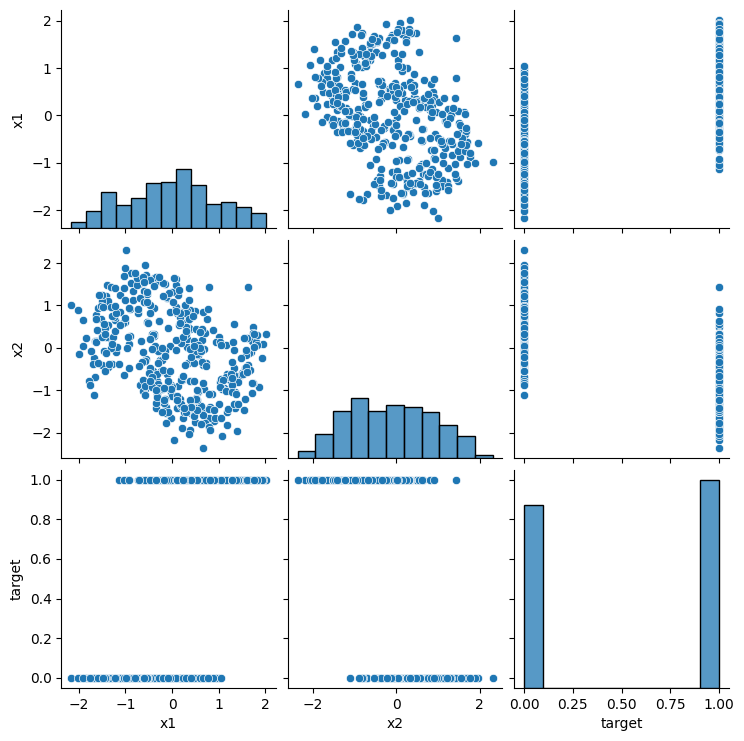

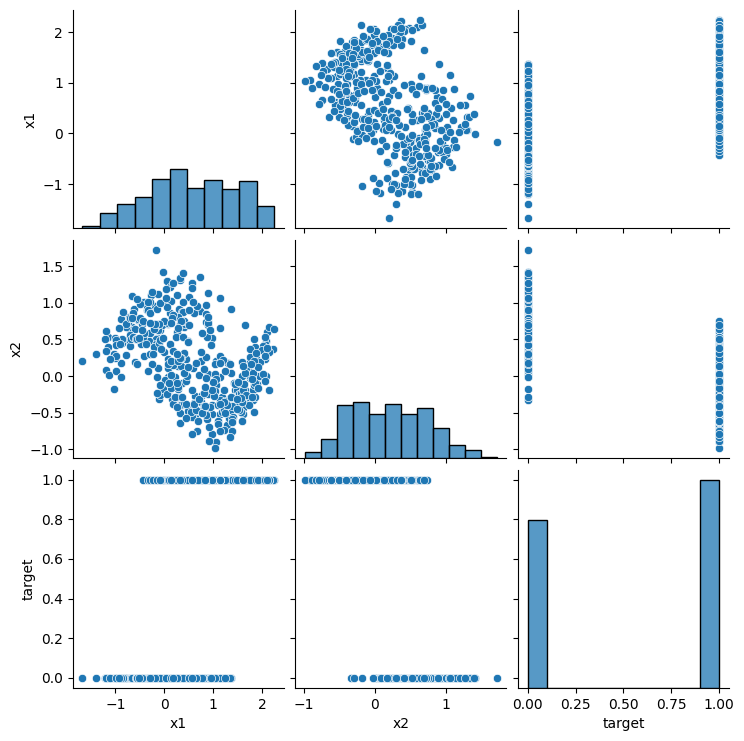

In [15]:
import seaborn as sns

sns.pairplot(val_proc)
sns.pairplot(synth_df)